# Triple-Barrier Method — 10 ativos B3

Pipeline baseado em Marcos López de Prado, *Advances in Financial Machine Learning* (Cap. 2 e 3).

**Estrutura do notebook:**
1. Setup
2. Coleta de dados (Yahoo Finance via `yfinance`) — salva em `Series/`
3. Conferência dos dados baixados
4. Funções do Triple-Barrier Method
5. Rodar o pipeline para os 10 ativos — salva rótulos em `Labels/`
6. Conferência dos resultados

> **Nota sobre barras de dólar/volume:** o livro recomenda usar barras de dólar em vez de barras de tempo (Seção 2.5). Isso exige dados intraday/tick, que o Yahoo Finance não fornece de graça. Aqui usamos barras diárias (cada linha do CSV = uma barra), que é a adaptação prática mais comum para dados de fechamento diário. O `Volume` é baixado e salvo mesmo assim, para você poder evoluir para barras de dólar depois, se conseguir uma fonte de dados intraday.


## 1. Setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)

# Pastas do projeto
SERIES_DIR = 'Series'   # onde ficam os preços brutos baixados do Yahoo Finance
LABELS_DIR = 'Labels'   # onde vão ficar os rótulos gerados pelo Triple-Barrier Method

os.makedirs(SERIES_DIR, exist_ok=True)
os.makedirs(LABELS_DIR, exist_ok=True)


## 2. Coleta de dados (Yahoo Finance)

Baixa o histórico diário de OHLCV para os 10 ativos e salva um CSV por ativo em `Series/`.

Rode esta célula com sua internet normal (fora de qualquer sandbox restrito). Se os CSVs já existirem em `Series/`, você pode pular esta célula e ir direto para a Parte 3.

In [ ]:
# ============================================================
# PARTE 1 - COLETA DE DADOS (Yahoo Finance via yfinance)
# ============================================================
# Esta célula baixa o histórico diário (Open, High, Low, Close, Volume)
# de cada ativo e salva um CSV por ativo na pasta Series/.
#
# ATENÇÃO: rode esta célula com sua conexão de internet normal.
# Se você já tiver os CSVs em Series/, pode pular esta célula.

import yfinance as yf

TICKERS = {
    "Vale": "VALE3.SA",
    "Itaú Unibanco": "ITUB4.SA",
    "Petrobras": "PETR4.SA",
    "Banco do Brasil": "BBAS3.SA",
    "Bradesco": "BBDC4.SA",
    "Ambev": "ABEV3.SA",
    "Weg": "WEGE3.SA",
    "Localiza": "RENT3.SA",
    "Suzano": "SUZB3.SA",
    "Taesa": "TAEE11.SA",
}

START_DATE = "2020-01-01"   # ajuste conforme a janela histórica que quiser
END_DATE = None              # None = até a data mais recente disponível

resumo = []
for empresa, ticker in TICKERS.items():
    print(f"Baixando {empresa} ({ticker})...")
    try:
        df = yf.Ticker(ticker).history(start=START_DATE, end=END_DATE, auto_adjust=True)
    except Exception as e:
        print(f"  ERRO ao baixar {ticker}: {e}")
        continue

    if df.empty:
        print(f"  ATENÇÃO: nenhum dado retornado para {ticker}")
        continue

    df = df.reset_index()[["Date", "Open", "High", "Low", "Close", "Volume"]]
    df["Date"] = pd.to_datetime(df["Date"]).dt.tz_localize(None)

    out_path = os.path.join(SERIES_DIR, f"{ticker.replace('.', '_')}.csv")
    df.to_csv(out_path, index=False)
    print(f"  Salvo em {out_path}  ({len(df)} linhas, {df['Date'].min().date()} a {df['Date'].max().date()})")
    resumo.append({"empresa": empresa, "ticker": ticker, "linhas": len(df),
                    "inicio": df["Date"].min().date(), "fim": df["Date"].max().date()})

print("\nConcluído.")
pd.DataFrame(resumo)


Baixando Vale (VALE3.SA)...
  Salvo em Series/VALE3_SA.csv  (1617 linhas, 2020-01-02 a 2026-07-01)
Baixando Itaú Unibanco (ITUB4.SA)...
  Salvo em Series/ITUB4_SA.csv  (1617 linhas, 2020-01-02 a 2026-07-01)
Baixando Petrobras (PETR4.SA)...
  Salvo em Series/PETR4_SA.csv  (1617 linhas, 2020-01-02 a 2026-07-01)
Baixando Banco do Brasil (BBAS3.SA)...
  Salvo em Series/BBAS3_SA.csv  (1617 linhas, 2020-01-02 a 2026-07-01)
Baixando Bradesco (BBDC4.SA)...
  Salvo em Series/BBDC4_SA.csv  (1617 linhas, 2020-01-02 a 2026-07-01)
Baixando Ambev (ABEV3.SA)...
  Salvo em Series/ABEV3_SA.csv  (1617 linhas, 2020-01-02 a 2026-07-01)
Baixando Weg (WEGE3.SA)...
  Salvo em Series/WEGE3_SA.csv  (1617 linhas, 2020-01-02 a 2026-07-01)
Baixando Localiza (RENT3.SA)...
  Salvo em Series/RENT3_SA.csv  (1617 linhas, 2020-01-02 a 2026-07-01)
Baixando Suzano (SUZB3.SA)...
  Salvo em Series/SUZB3_SA.csv  (1617 linhas, 2020-01-02 a 2026-07-01)
Baixando Taesa (TAEE11.SA)...
  Salvo em Series/TAEE11_SA.csv  (1617 linha

,empresa,ticker,linhas,inicio,fim
0,Vale,VALE3.SA,1617,2020-01-02,2026-07-01
1,Itaú Unibanco,ITUB4.SA,1617,2020-01-02,2026-07-01
2,Petrobras,PETR4.SA,1617,2020-01-02,2026-07-01
3,Banco do Brasil,BBAS3.SA,1617,2020-01-02,2026-07-01
4,Bradesco,BBDC4.SA,1617,2020-01-02,2026-07-01
5,Ambev,ABEV3.SA,1617,2020-01-02,2026-07-01
6,Weg,WEGE3.SA,1617,2020-01-02,2026-07-01
7,Localiza,RENT3.SA,1617,2020-01-02,2026-07-01
8,Suzano,SUZB3.SA,1617,2020-01-02,2026-07-01
9,Taesa,TAEE11.SA,1617,2020-01-02,2026-07-01


## 3. Conferência dos dados baixados

10 arquivos encontrados em Series/:
 - ABEV3_SA.csv
 - BBAS3_SA.csv
 - BBDC4_SA.csv
 - ITUB4_SA.csv
 - PETR4_SA.csv
 - RENT3_SA.csv
 - SUZB3_SA.csv
 - TAEE11_SA.csv
 - VALE3_SA.csv
 - WEGE3_SA.csv


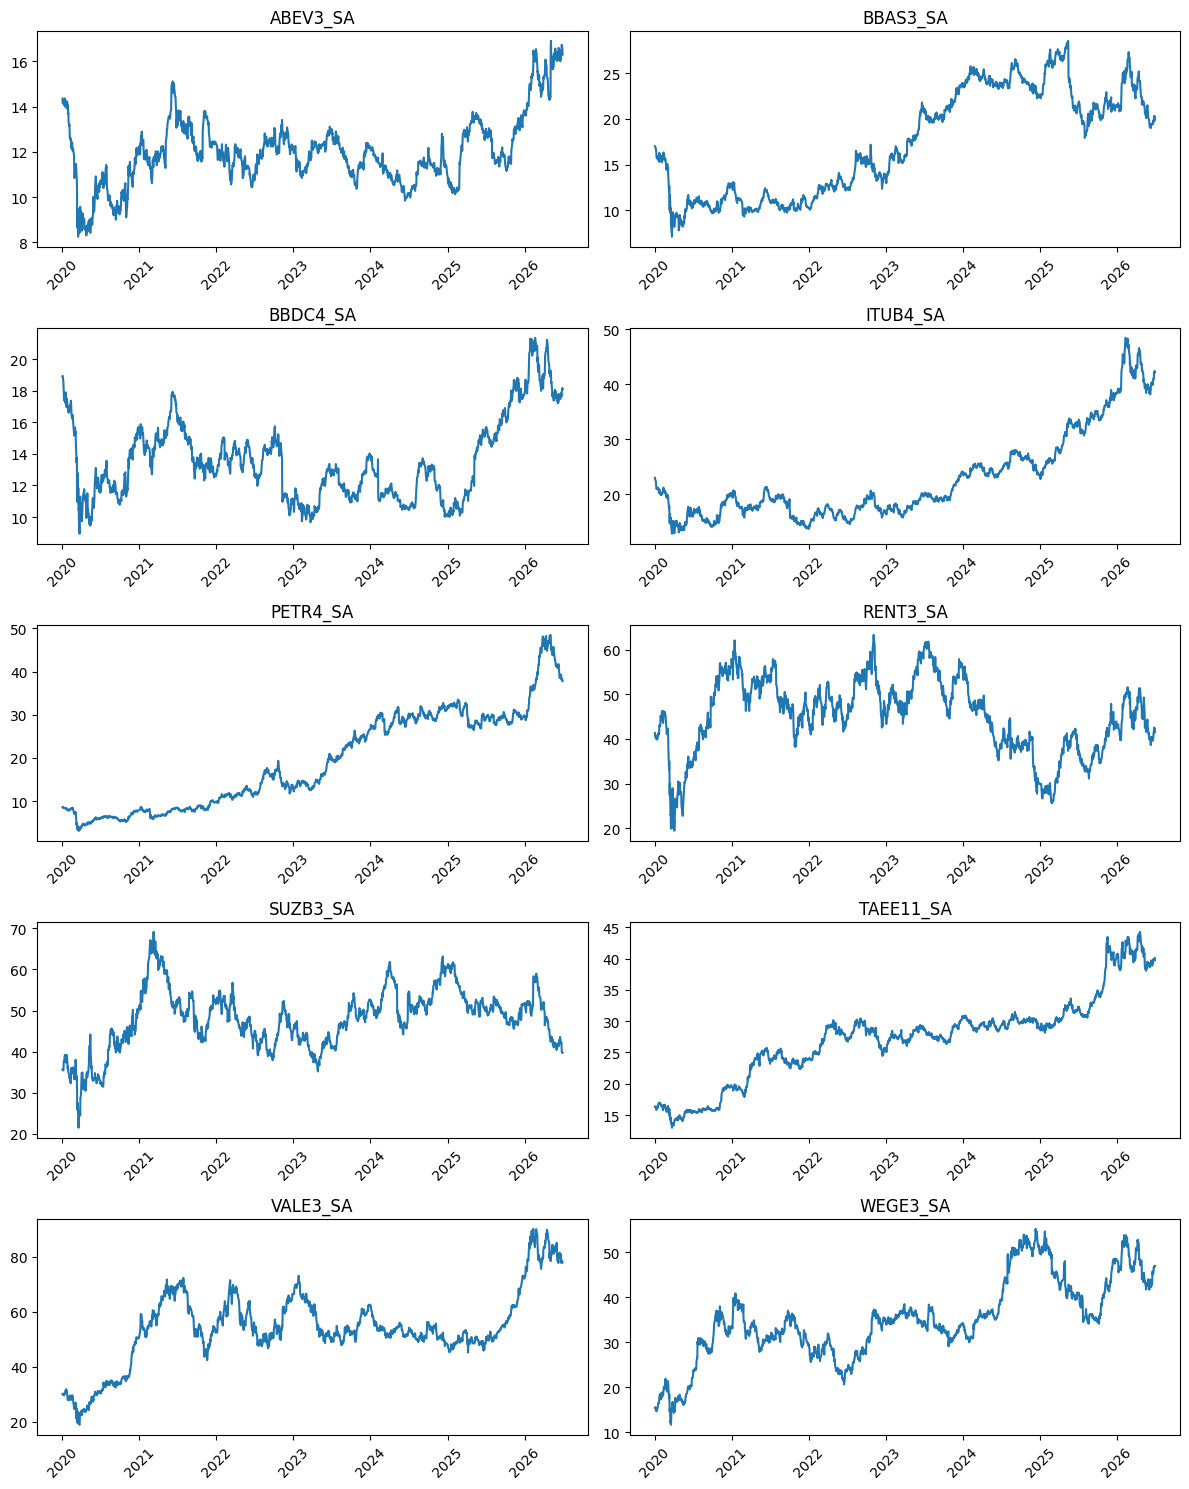

,ativo,linhas,inicio,fim,ultimo_close
0,ABEV3_SA,1616,2020-01-02,2026-06-30,16.29
1,BBAS3_SA,1616,2020-01-02,2026-06-30,19.91
2,BBDC4_SA,1616,2020-01-02,2026-06-30,18.10
3,ITUB4_SA,1616,2020-01-02,2026-06-30,42.16
4,PETR4_SA,1616,2020-01-02,2026-06-30,37.80
5,RENT3_SA,1616,2020-01-02,2026-06-30,41.54
6,SUZB3_SA,1616,2020-01-02,2026-06-30,39.75
7,TAEE11_SA,1616,2020-01-02,2026-06-30,39.78
8,VALE3_SA,1616,2020-01-02,2026-06-30,77.88
9,WEGE3_SA,1616,2020-01-02,2026-06-30,46.91


In [2]:
# ============================================================
# PARTE 2 - CONFERÊNCIA DOS DADOS BAIXADOS
# ============================================================
csv_files = sorted(glob.glob(os.path.join(SERIES_DIR, '*.csv')))
print(f"{len(csv_files)} arquivos encontrados em {SERIES_DIR}/:")
for f in csv_files:
    print(" -", os.path.basename(f))

# Visualiza o preço de fechamento de TODOS os ativos baixados (grid de subplots)
if csv_files:
    n = len(csv_files)
    ncols = 2
    nrows = -(-n // ncols)  # arredonda pra cima
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
    axes = axes.flatten()

    for ax, f in zip(axes, csv_files):
        df_check = pd.read_csv(f, parse_dates=['Date'])
        ax.plot(df_check['Date'], df_check['Close'])
        ax.set_title(os.path.basename(f).replace('.csv', ''))
        ax.tick_params(axis='x', rotation=45)

    # apaga eixos vazios sobrando, se o número de ativos for ímpar
    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # tabela resumo (linhas, período, último preço)
    resumo_check = []
    for f in csv_files:
        df_check = pd.read_csv(f, parse_dates=['Date'])
        resumo_check.append({
            'ativo': os.path.basename(f).replace('.csv', ''),
            'linhas': len(df_check),
            'inicio': df_check['Date'].min().date(),
            'fim': df_check['Date'].max().date(),
            'ultimo_close': round(df_check['Close'].iloc[-1], 2),
        })
    display(pd.DataFrame(resumo_check))



## 4. Funções do Triple-Barrier Method

Implementação das funções do livro:
- `getDailyVol` (Snippet 3.1) — volatilidade diária via EWMA
- `cusum_filter` (Snippet 2.4) — filtro CUSUM para gerar os eventos (tEvents)
- `add_vertical_barrier` — barreira vertical (t1)
- `apply_pt_sl_on_t1` (Snippet 3.2) — aplica as 3 barreiras
- `get_events` (Snippet 3.3) — monta o dataframe de eventos
- `get_bins` (Snippet 3.5) — converte toques de barreira em rótulos {-1, 0, 1}


In [3]:
# ============================================================
# PARTE 3 - FUNÇÕES DO TRIPLE-BARRIER METHOD
# (Marcos López de Prado, "Advances in Financial Machine Learning", Cap. 2 e 3)
# ============================================================
# Como só temos dados diários (sem tick/intraday), usamos cada linha do
# CSV como uma "barra" -- ou seja, aplicamos o método sobre barras de tempo
# diárias, e não sobre barras de dólar/volume "reais" (que exigiriam dados
# intraday). É uma simplificação necessária dado o dado disponível, mas o
# método de rotulagem em si (a parte central do capítulo 3) é implementado
# fielmente.


def get_daily_vol(close: pd.Series, span0: int = 100) -> pd.Series:
    """Volatilidade diária via EWMA dos retornos (Snippet 3.1)."""
    df0 = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    df0 = df0[df0 > 0]
    df0 = pd.Series(close.index[df0 - 1], index=close.index[close.shape[0] - df0.shape[0]:])
    df0 = close.loc[df0.index] / close.loc[df0.values].values - 1
    return df0.ewm(span=span0).std()


def cusum_filter(close: pd.Series, threshold) -> pd.DatetimeIndex:
    """Filtro CUSUM simétrico para gerar os eventos (tEvents) (Snippet 2.4)."""
    t_events, s_pos, s_neg = [], 0, 0
    diff = close.diff().dropna()
    is_series = isinstance(threshold, pd.Series)

    for t in diff.index:
        if is_series:
            h = threshold.loc[t] if t in threshold.index else np.nan
        else:
            h = threshold
        if pd.isna(h):
            continue
        s_pos = max(0, s_pos + diff.loc[t])
        s_neg = min(0, s_neg + diff.loc[t])
        if s_neg < -h:
            s_neg = 0
            t_events.append(t)
        elif s_pos > h:
            s_pos = 0
            t_events.append(t)
    return pd.DatetimeIndex(t_events)


def add_vertical_barrier(t_events: pd.DatetimeIndex, close: pd.Series, num_bars: int = 5) -> pd.Series:
    """Define t1 (barreira vertical / limite de tempo) num_bars barras à frente."""
    idx_pos = close.index.searchsorted(t_events)
    t1 = []
    for t, pos in zip(t_events, idx_pos):
        target_pos = pos + num_bars
        t1.append(close.index[target_pos] if target_pos < len(close) else pd.NaT)
    return pd.Series(t1, index=t_events, name='t1')


def apply_pt_sl_on_t1(close: pd.Series, events: pd.DataFrame, pt_sl: list) -> pd.DataFrame:
    """Aplica as 3 barreiras e retorna o primeiro toque de cada uma (Snippet 3.2)."""
    out = events[['t1']].copy(deep=True)

    pt = pt_sl[0] * events['trgt'] if pt_sl[0] > 0 else pd.Series(index=events.index, dtype=float)
    sl = -pt_sl[1] * events['trgt'] if pt_sl[1] > 0 else pd.Series(index=events.index, dtype=float)

    for loc, t1 in events['t1'].fillna(close.index[-1]).items():
        df0 = close[loc:t1]
        df0 = (df0 / close[loc] - 1) * events.at[loc, 'side']
        out.loc[loc, 'sl'] = df0[df0 < sl[loc]].index.min() if not pd.isna(sl[loc]) else pd.NaT
        out.loc[loc, 'pt'] = df0[df0 > pt[loc]].index.min() if not pd.isna(pt[loc]) else pd.NaT

    return out


def get_events(close, t_events, pt_sl, trgt, min_ret=0.0, t1=None, side=None) -> pd.DataFrame:
    """Monta o dataframe de eventos e aplica a barreira tripla (Snippet 3.3, single-thread)."""
    trgt = trgt.reindex(t_events).dropna()
    trgt = trgt[trgt > min_ret]

    if t1 is None:
        t1 = pd.Series(pd.NaT, index=t_events)

    if side is None:
        side_ = pd.Series(1.0, index=trgt.index)
        pt_sl_ = [pt_sl, pt_sl] if not isinstance(pt_sl, (list, tuple)) else pt_sl
    else:
        side_ = side.reindex(trgt.index)
        pt_sl_ = pt_sl

    events = pd.concat({'t1': t1.reindex(trgt.index), 'trgt': trgt, 'side': side_}, axis=1).dropna(subset=['trgt'])

    df0 = apply_pt_sl_on_t1(close, events, pt_sl_)
    events['t1'] = df0[['sl', 'pt', 't1']].dropna(how='all').min(axis=1)

    if side is None:
        events = events.drop('side', axis=1)

    return events


def get_bins(events: pd.DataFrame, close: pd.Series) -> pd.DataFrame:
    """Converte os toques de barreira em rótulos {-1, 0, 1} (Snippet 3.5)."""
    events_ = events.dropna(subset=['t1'])
    px = events_.index.union(events_['t1'].values).drop_duplicates()
    px = close.reindex(px, method='bfill')

    out = pd.DataFrame(index=events_.index)
    out['ret'] = px.loc[events_['t1'].values].values / px.loc[events_.index] - 1

    if 'side' in events_:
        out['ret'] *= events_['side']

    out['bin'] = np.sign(out['ret'])
    if 'side' not in events_:
        out.loc[out['ret'] == 0, 'bin'] = 0
    if 'side' in events_:
        out['side'] = events_['side']

    return out


def run_pipeline_for_asset(csv_path, span0=20, cusum_mult=1.0, num_bars_vertical=5,
                            pt_sl=(1, 1), min_ret=0.0, scale_by_horizon=True) -> pd.DataFrame:
    """Pipeline completo: getDailyVol -> CUSUM -> vertical barrier -> triple barrier -> getBins.

    scale_by_horizon: se True (padrão), a largura das barreiras horizontais (trgt) é
        escalada por sqrt(num_bars_vertical), seguindo a regra clássica de que a
        volatilidade cresce com a raiz do tempo (random walk). Isso é essencial quando
        num_bars_vertical é grande (médio/longo prazo) -- sem escalar, a barreira
        horizontal fica do tamanho de 1 dia enquanto o preço caminha por dezenas de
        dias, e ela é estourada quase sempre nos primeiros dias, distorcendo os
        rótulos. Para horizontes curtos (poucos dias) o efeito é pequeno, mas para
        horizontes longos ele é decisivo.
    """
    name = os.path.splitext(os.path.basename(csv_path))[0]

    df = pd.read_csv(csv_path, parse_dates=['Date']).sort_values('Date')
    df = df.drop_duplicates(subset='Date').set_index('Date')
    close = df['Close'].astype(float)

    daily_vol = get_daily_vol(close, span0=span0)
    t_events = cusum_filter(close, daily_vol * cusum_mult)

    if len(t_events) == 0:
        print(f"[{name}] Nenhum evento CUSUM disparado -- ajuste cusum_mult/span0.")
        return pd.DataFrame()

    t1 = add_vertical_barrier(t_events, close, num_bars=num_bars_vertical)

    # largura das barreiras horizontais: vol diária escalada para o horizonte da barreira vertical
    trgt = daily_vol * np.sqrt(num_bars_vertical) if scale_by_horizon else daily_vol

    events = get_events(close, t_events, pt_sl=list(pt_sl), trgt=trgt,
                         min_ret=min_ret, t1=t1, side=None)

    bins = get_bins(events, close)
    bins.insert(0, 'asset', name)
    bins.index.name = "Date"
    return bins


## 5. Rodar o pipeline para os 10 ativos

Ajuste os parâmetros em `PARAMS` para calibrar o método (sensibilidade do CUSUM, largura das barreiras, holding period).

In [4]:
# ============================================================
# PARTE 4 - RODAR O TRIPLE-BARRIER METHOD PARA OS 10 ATIVOS
# ============================================================
# Ajuste estes parâmetros conforme quiser calibrar o método:
PARAMS = dict(
    span0=60,               # janela da EWMA de volatilidade (~3 meses úteis)
    cusum_mult=1.5,         # limiar do CUSUM = cusum_mult * vol diária (menos eventos, mais relevantes)
    num_bars_vertical=40,   # barreira vertical: ~2 meses úteis (holding period de médio/longo prazo)
    pt_sl=(1, 1),           # [profit-taking, stop-loss] em múltiplos de trgt (já escalado pelo horizonte)
    min_ret=0.0,
    scale_by_horizon=True,  # essencial: escala as barreiras horizontais por sqrt(num_bars_vertical)
)

csv_files = sorted(glob.glob(os.path.join(SERIES_DIR, '*.csv')))
all_bins = []

for path in csv_files:
    bins = run_pipeline_for_asset(path, **PARAMS)
    if not bins.empty:
        asset = bins['asset'].iloc[0]
        out_path = os.path.join(LABELS_DIR, f"{asset}_labels.csv")
        bins.to_csv(out_path)
        print(f"[{asset}] {len(bins)} eventos rotulados -> {out_path} | "
              f"distribuição: {bins['bin'].value_counts().to_dict()}")
        all_bins.append(bins)

if all_bins:
    combined = pd.concat(all_bins)
    combined.to_csv(os.path.join(LABELS_DIR, 'all_assets_labels.csv'))
    print(f"\nArquivo combinado salvo em {os.path.join(LABELS_DIR, 'all_assets_labels.csv')}")
    print(f"Total de eventos rotulados: {len(combined)}")

[ABEV3_SA] 1324 eventos rotulados -> Labels\ABEV3_SA_labels.csv | distribuição: {1.0: 711, -1.0: 608, 0.0: 5}
[BBAS3_SA] 1387 eventos rotulados -> Labels\BBAS3_SA_labels.csv | distribuição: {1.0: 771, -1.0: 616}
[BBDC4_SA] 1357 eventos rotulados -> Labels\BBDC4_SA_labels.csv | distribuição: {1.0: 705, -1.0: 652}
[ITUB4_SA] 1451 eventos rotulados -> Labels\ITUB4_SA_labels.csv | distribuição: {1.0: 830, -1.0: 621}
[PETR4_SA] 1360 eventos rotulados -> Labels\PETR4_SA_labels.csv | distribuição: {1.0: 918, -1.0: 442}
[RENT3_SA] 1507 eventos rotulados -> Labels\RENT3_SA_labels.csv | distribuição: {1.0: 828, -1.0: 679}
[SUZB3_SA] 1498 eventos rotulados -> Labels\SUZB3_SA_labels.csv | distribuição: {1.0: 765, -1.0: 733}
[TAEE11_SA] 1461 eventos rotulados -> Labels\TAEE11_SA_labels.csv | distribuição: {1.0: 815, -1.0: 644, 0.0: 2}
[VALE3_SA] 1511 eventos rotulados -> Labels\VALE3_SA_labels.csv | distribuição: {1.0: 869, -1.0: 642}
[WEGE3_SA] 1474 eventos rotulados -> Labels\WEGE3_SA_labels.csv 

## 6. Conferência dos resultados

bin,-1.0,0.0,1.0
asset,,,
ABEV3_SA,608,5,711
BBAS3_SA,616,0,771
BBDC4_SA,652,0,705
ITUB4_SA,621,0,830
PETR4_SA,442,0,918
RENT3_SA,679,0,828
SUZB3_SA,733,0,765
TAEE11_SA,644,2,815
VALE3_SA,642,0,869


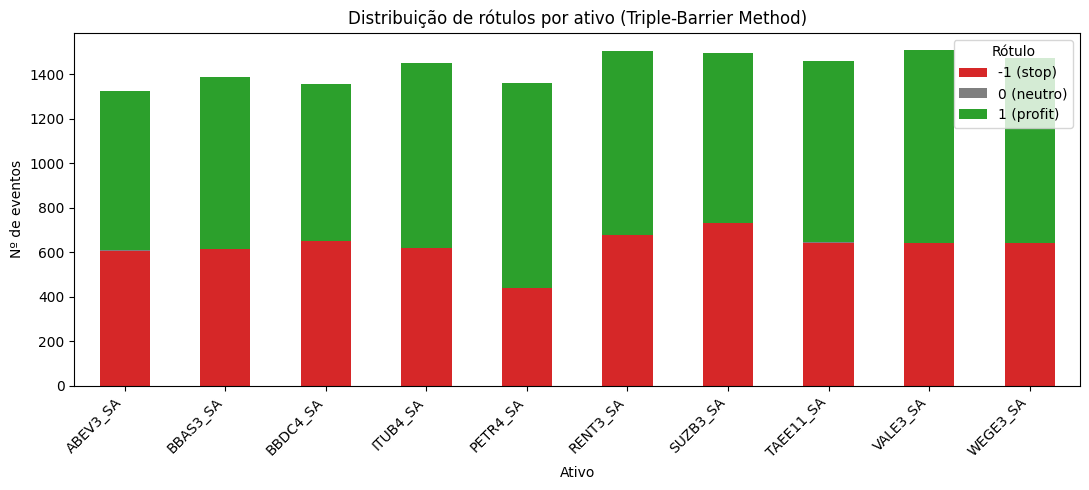

In [5]:
# ============================================================
# PARTE 5 - CONFERÊNCIA DOS RESULTADOS
# ============================================================
if all_bins:
    combined = pd.concat(all_bins)

    # Distribuição de rótulos por ativo
    dist = combined.groupby('asset')['bin'].value_counts().unstack(fill_value=0)
    display(dist)

    dist.plot(kind='bar', stacked=True, figsize=(11, 5), color=['#d62728', '#7f7f7f', '#2ca02c'])
    plt.title("Distribuição de rótulos por ativo (Triple-Barrier Method)")
    plt.ylabel("Nº de eventos")
    plt.xlabel("Ativo")
    plt.legend(title="Rótulo", labels=['-1 (stop)', '0 (neutro)', '1 (profit)'])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum resultado para exibir -- rode a Parte 4 primeiro.")


## 7. Gerar matriz de features

In [7]:
from sklearn.preprocessing import StandardScaler
from pathlib import Path

def process_single_asset(price_path, label_path, lookback=30):
    """Processes a single pair of price/label CSVs into scaled 3D windows."""
    # load the data
    df = pd.read_csv(price_path, parse_dates=['Date']).set_index('Date')
    labels = pd.read_csv(label_path, parse_dates=['Date']).set_index('Date')
    
    # feature engineering
    # could possibly change later (?)
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    df['HL_Spread'] = np.log(df['High'] / df['Low'])
    df['CO_Return'] = np.log(df['Close'] / df['Open'])
    df['Rolling_Vol'] = df['Log_Return'].rolling(window=20).std()
    df['Close_to_Vol'] = df['Log_Return'] / (df['Rolling_Vol'] + 1e-8)
    
    feature_cols = ['Log_Return', 'HL_Spread', 'CO_Return', 'Rolling_Vol', 'Close_to_Vol']
    
    # Align features with labels
    combined_df = df[feature_cols].copy()
    
    # Find the correct column name in the label file (handles if it's named 'Label', 'target', etc.)
    label_col = labels.columns[0]
    combined_df['Target_Label'] = labels[label_col]
    
    combined_df.dropna(inplace=True)
    
    if len(combined_df) < lookback:
        return None, None
        
    X_raw = combined_df[feature_cols].values
    y_raw = combined_df['Target_Label'].values
    
    # Scale this asset individually
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    # build 3D windows
    X_3D, y_aligned = [], []
    for i in range(len(X_scaled) - lookback + 1):
        X_3D.append(X_scaled[i : i + lookback])
        y_aligned.append(y_raw[i + lookback - 1])
        
    return np.array(X_3D), np.array(y_aligned)


def load_all_assets(series_dir, labels_dir, lookback=30):
    """Loops through folders, matches assets, and aggregates into a final dataset."""
    series_path = Path(series_dir)
    labels_path = Path(labels_dir)
    
    X_all = []
    y_all = []
    
    # go through all the files in our series folder
    for file_path in series_path.glob("*.csv"):
        asset_name = file_path.stem # e.g., 'PETR4_SA'
        
        corresponding_label_file = labels_path / f"{asset_name}_labels.csv"
        
        if corresponding_label_file.exists():
            print(f"Processando: {asset_name}...")
            X_asset, y_asset = process_single_asset(file_path, corresponding_label_file, lookback)
            
            if X_asset is not None:
                X_all.append(X_asset)
                y_all.append(y_asset)
        else:
            print(f"Nao foi encontrado arquivo de rotulo correspondente a {asset_name}")
            
    # Concatenate all assets along the sample axis (axis 0)
    X_final = np.concatenate(X_all, axis=0)
    y_final = np.concatenate(y_all, axis=0)
    
    return X_final, y_final



LOOKBACK = 30 # how many days do we look back for a prediction

X, y = load_all_assets(SERIES_DIR, LABELS_DIR, lookback=LOOKBACK)

print("\nShape")
print("Combined X Shape:", X.shape) # expected: (total_sample 30, 5)
print("Combined y Shape:", y.shape) # expected: (total_sample,)

# for now we're merging every series and labels into one big thing to feed the ai model. we could change that later if convenient
# in general, given X[i], the ai model wants to try to find y[i]

Processando: ABEV3_SA...
Processando: BBAS3_SA...
Processando: BBDC4_SA...
Processando: ITUB4_SA...
Processando: PETR4_SA...
Processando: RENT3_SA...
Processando: SUZB3_SA...
Processando: TAEE11_SA...
Processando: VALE3_SA...
Processando: WEGE3_SA...

Shape
Combined X Shape: (13880, 30, 5)
Combined y Shape: (13880,)
